본 노트북은 hyperparameter_tuning에서 결과로 나오게된 loss_acc_log을 분석하기 위해 제작된 노트북 입니다.

In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import ast

In [8]:
# windows의 경우
# plt.rcParams['font.family'] = 'Malgun Gothic'

# mac의 경우
plt.rcParams['font.family'] = 'AppleGothic'

In [9]:
file_path = '../../log/loss_acc_log.csv'
df = pd.read_csv(file_path)

In [10]:
# hidden_size_list 문자열 → 리스트 변환
df["hidden_size_list"] = df["hidden_size_list"].apply(lambda x: ast.literal_eval(x))

df.head()

,optimizer,lr,batch_size,max_iterations,max_epochs,hidden_size_list,activation,weight_init_std,weight_decay_lambda,use_batchnorm,dropout_ration,final_loss,final_acc
0,Adam,0.001,128,200,200,"[64, 64, 64]",relu,relu,0.0000,False,0.0,0.489533,0.829
1,Adam,0.001,128,200,200,"[64, 64, 64]",relu,relu,0.0000,False,0.3,0.715597,0.779
2,Adam,0.001,128,200,200,"[64, 64, 64]",relu,relu,0.0001,False,0.0,0.564426,0.814
3,Adam,0.001,128,200,200,"[64, 64, 64]",relu,relu,0.0001,False,0.3,0.762968,0.767
4,Adam,0.001,128,200,200,"[64, 64, 64, 64, 64]",relu,relu,0.0000,False,0.0,0.496112,0.812


In [11]:
# 3. 기본 통계 요약
print("===== 기본 통계 요약 =====")
display(df.describe())

print("\n===== 하이퍼파라미터 구성 =====")
for col in ["optimizer","lr","batch_size","activation","use_batchnorm","dropout_ration"]:
    print(f"\n▶ {col} 값 분포")
    print(df[col].value_counts())


===== 기본 통계 요약 =====


,lr,batch_size,max_iterations,max_epochs,weight_decay_lambda,dropout_ration,final_loss,final_acc
count,32.000000,32.000000,32.0,32.0,32.000000,32.0000,32.000000,32.000000
mean,0.000550,192.000000,200.0,200.0,0.000050,0.1500,1.015430,0.689938
std,0.000457,65.024065,0.0,0.0,0.000051,0.1524,0.531498,0.143436
min,0.000100,128.000000,200.0,200.0,0.000000,0.0000,0.489533,0.301000
25%,0.000100,128.000000,200.0,200.0,0.000000,0.0000,0.628711,0.629000
50%,0.000550,192.000000,200.0,200.0,0.000050,0.1500,0.842670,0.734000
75%,0.001000,256.000000,200.0,200.0,0.000100,0.3000,1.188043,0.787500
max,0.001000,256.000000,200.0,200.0,0.000100,0.3000,2.194874,0.843000



===== 하이퍼파라미터 구성 =====

▶ optimizer 값 분포
optimizer
Adam    32
Name: count, dtype: int64

▶ lr 값 분포
lr
0.0010    16
0.0001    16
Name: count, dtype: int64

▶ batch_size 값 분포
batch_size
128    16
256    16
Name: count, dtype: int64

▶ activation 값 분포
activation
relu    32
Name: count, dtype: int64

▶ use_batchnorm 값 분포
use_batchnorm
False    32
Name: count, dtype: int64

▶ dropout_ration 값 분포
dropout_ration
0.0    16
0.3    16
Name: count, dtype: int64


In [12]:
# 4. 성능 상위 5개 모델 출력
top5 = df.sort_values(by="final_acc", ascending=False).head(5)
print("===== 성능 상위 5개 모델 =====")
display(top5)


===== 성능 상위 5개 모델 =====


,optimizer,lr,batch_size,max_iterations,max_epochs,hidden_size_list,activation,weight_init_std,weight_decay_lambda,use_batchnorm,dropout_ration,final_loss,final_acc
12,Adam,0.001,256,200,200,"[64, 64, 64, 64, 64]",relu,relu,0.0000,False,0.0,0.490767,0.843
8,Adam,0.001,256,200,200,"[64, 64, 64]",relu,relu,0.0000,False,0.0,0.492904,0.841
14,Adam,0.001,256,200,200,"[64, 64, 64, 64, 64]",relu,relu,0.0001,False,0.0,0.522747,0.840
10,Adam,0.001,256,200,200,"[64, 64, 64]",relu,relu,0.0001,False,0.0,0.514151,0.830
0,Adam,0.001,128,200,200,"[64, 64, 64]",relu,relu,0.0000,False,0.0,0.489533,0.829


/opt/homebrew/lib/python3.11/site-packages/seaborn/categorical.py:1273: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(aggregator, agg_var)


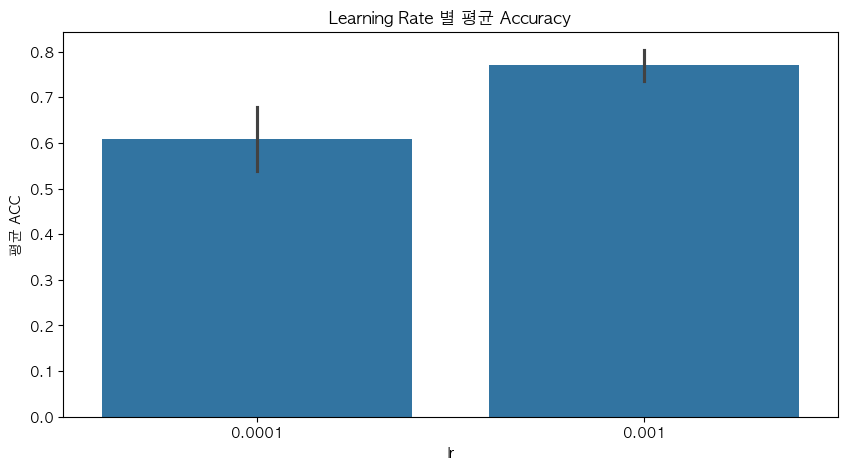

/opt/homebrew/lib/python3.11/site-packages/seaborn/categorical.py:1273: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(aggregator, agg_var)


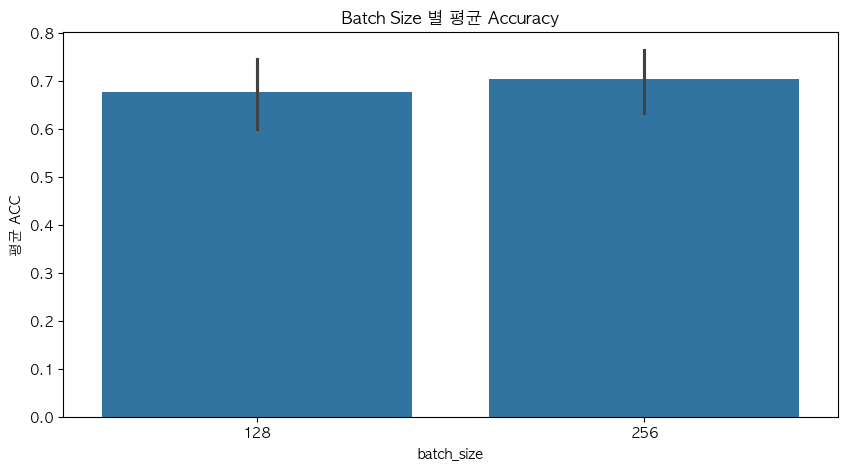

/opt/homebrew/lib/python3.11/site-packages/seaborn/categorical.py:1273: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(aggregator, agg_var)


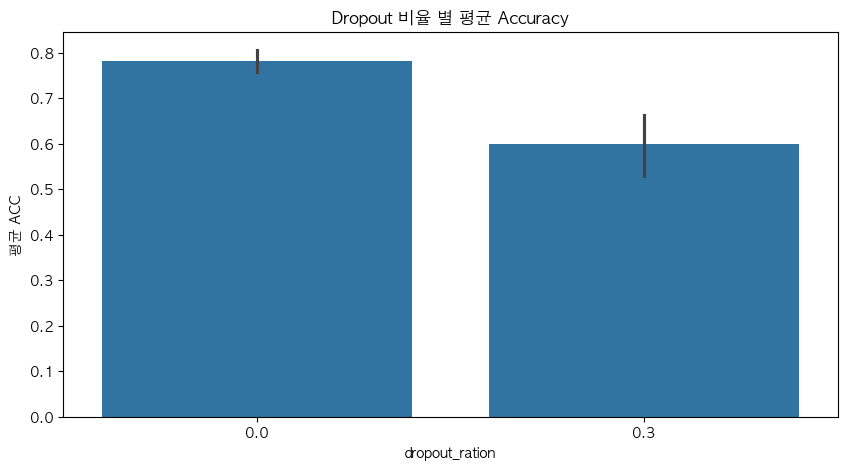

/opt/homebrew/lib/python3.11/site-packages/seaborn/categorical.py:1273: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(aggregator, agg_var)


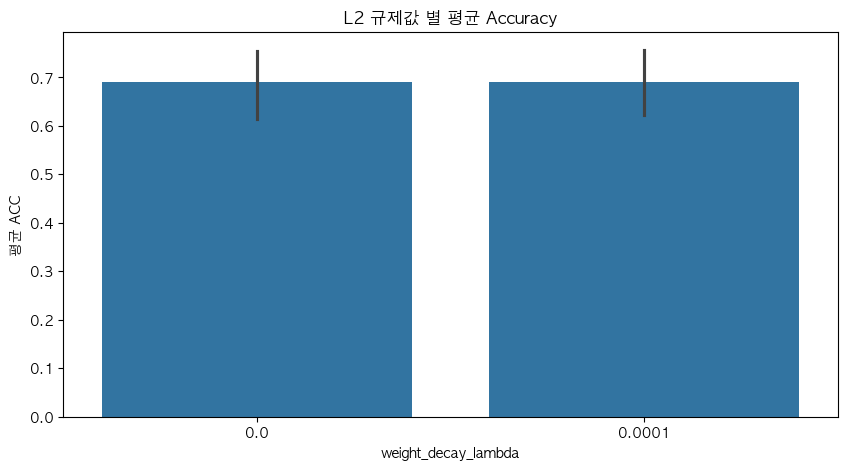

In [ ]:
# 5. 하이퍼파라미터별 ACC 평균 비교

def plot_bar(col, title):
    plt.figure(figsize=(10,5))
    sns.barplot(x=df[col], y=df["final_acc"])
    plt.title(title)
    plt.ylabel("평균 ACC")
    plt.show()

plot_bar("lr", "Learning Rate 별 평균 Accuracy")
plot_bar("batch_size", "Batch Size 별 평균 Accuracy")
plot_bar("dropout_ration", "Dropout 비율 별 평균 Accuracy")
plot_bar("weight_decay_lambda", "L2 규제값 별 평균 Accuracy")


/opt/homebrew/lib/python3.11/site-packages/seaborn/categorical.py:632: FutureWarning: SeriesGroupBy.grouper is deprecated and will be removed in a future version of pandas.
  positions = grouped.grouper.result_index.to_numpy(dtype=float)


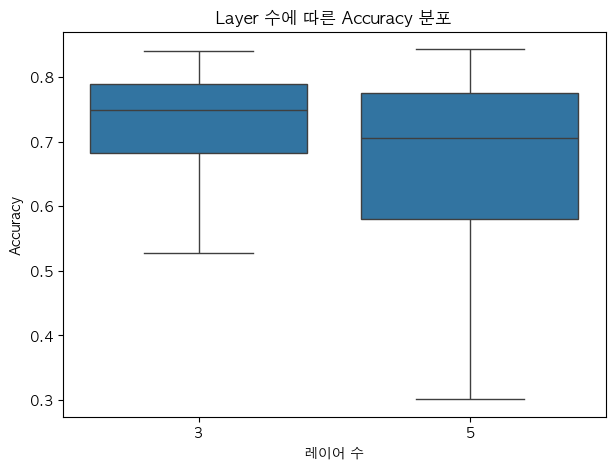

num_layers
3    0.726875
5    0.653000
Name: final_acc, dtype: float64

In [14]:
# 6. 네트워크 깊이(hidden layer 수)와 성능 관계
df["num_layers"] = df["hidden_size_list"].apply(len)

plt.figure(figsize=(7,5))
sns.boxplot(x=df["num_layers"], y=df["final_acc"])
plt.title("Layer 수에 따른 Accuracy 분포")
plt.xlabel("레이어 수")
plt.ylabel("Accuracy")
plt.show()

df.groupby("num_layers")["final_acc"].mean()


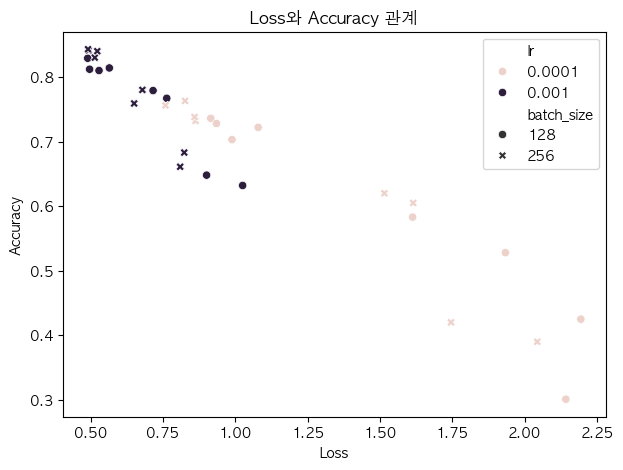

In [15]:
# 7. Loss vs Accuracy 관계
plt.figure(figsize=(7,5))
sns.scatterplot(x="final_loss", y="final_acc", data=df, hue="lr", style="batch_size")
plt.title("Loss와 Accuracy 관계")
plt.xlabel("Loss")
plt.ylabel("Accuracy")
plt.show()


/opt/homebrew/lib/python3.11/site-packages/seaborn/categorical.py:632: FutureWarning: SeriesGroupBy.grouper is deprecated and will be removed in a future version of pandas.
  positions = grouped.grouper.result_index.to_numpy(dtype=float)


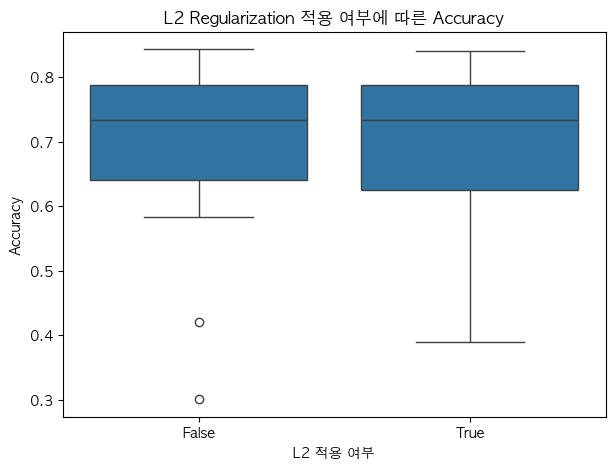

In [16]:
# 8. L2 규제 여부에 따른 성능 차이

df["L2_on"] = df["weight_decay_lambda"] > 0

plt.figure(figsize=(7,5))
sns.boxplot(x=df["L2_on"], y=df["final_acc"])
plt.title("L2 Regularization 적용 여부에 따른 Accuracy")
plt.xlabel("L2 적용 여부")
plt.ylabel("Accuracy")
plt.show()


/opt/homebrew/lib/python3.11/site-packages/seaborn/categorical.py:632: FutureWarning: SeriesGroupBy.grouper is deprecated and will be removed in a future version of pandas.
  positions = grouped.grouper.result_index.to_numpy(dtype=float)


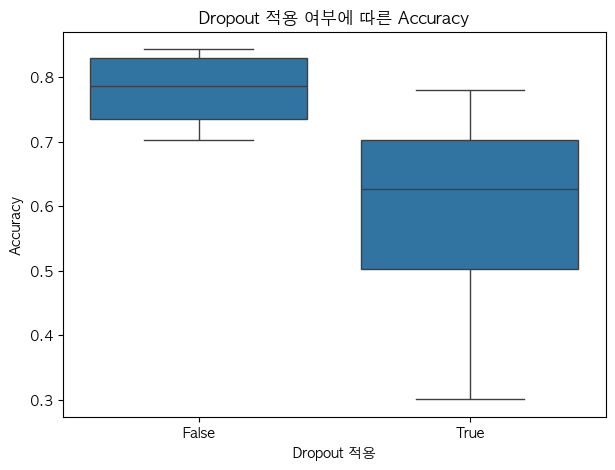

In [17]:
# 9. Dropout 적용 여부에 따른 성능 비교

df["dropout_on"] = df["dropout_ration"] > 0

plt.figure(figsize=(7,5))
sns.boxplot(x=df["dropout_on"], y=df["final_acc"])
plt.title("Dropout 적용 여부에 따른 Accuracy")
plt.xlabel("Dropout 적용")
plt.ylabel("Accuracy")
plt.show()


/opt/homebrew/lib/python3.11/site-packages/seaborn/utils.py:84: UserWarning: Glyph 8722 (\N{MINUS SIGN}) missing from current font.
  fig.canvas.draw()
/Users/wonjong-u/Library/Python/3.11/lib/python/site-packages/IPython/core/pylabtools.py:152: UserWarning: Glyph 8722 (\N{MINUS SIGN}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)


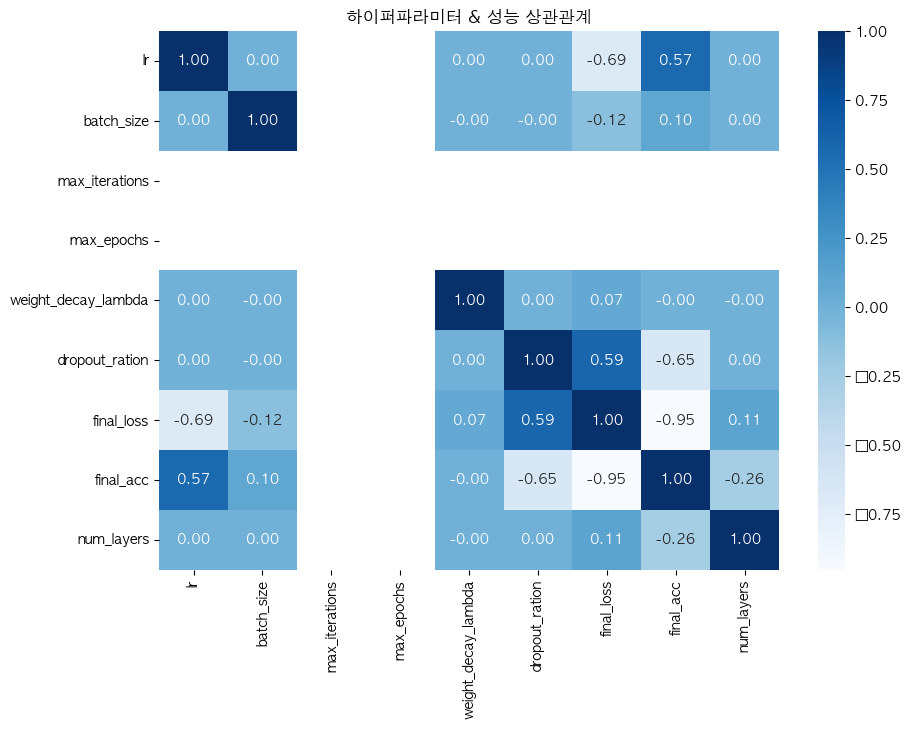

In [18]:
# 10. 상관관계 분석 (숫자형만)

numeric_df = df.select_dtypes(include=[np.number])

plt.figure(figsize=(10, 7))
sns.heatmap(numeric_df.corr(), annot=True, fmt=".2f", cmap="Blues")
plt.title("하이퍼파라미터 & 성능 상관관계")
plt.show()


In [19]:
# 11. 최종 결론 요약 출력

print("===== 분석 요약 =====")

best_model = df.sort_values(by="final_acc", ascending=False).iloc[0]
print("\n▶ 최고 성능 모델")
print(best_model)

print("\n▶ Layer 수별 평균 Accuracy")
print(df.groupby("num_layers")["final_acc"].mean())

print("\n▶ Dropout 여부에 따른 Accuracy 평균")
print(df.groupby("dropout_on")["final_acc"].mean())

print("\n▶ L2 Regularization 여부에 따른 Accuracy 평균")
print(df.groupby("L2_on")["final_acc"].mean())


===== 분석 요약 =====

▶ 최고 성능 모델
optimizer                              Adam
lr                                    0.001
batch_size                              256
max_iterations                          200
max_epochs                              200
hidden_size_list       [64, 64, 64, 64, 64]
activation                             relu
weight_init_std                        relu
weight_decay_lambda                     0.0
use_batchnorm                         False
dropout_ration                          0.0
final_loss                         0.490767
final_acc                             0.843
num_layers                                5
L2_on                                 False
dropout_on                            False
Name: 12, dtype: object

▶ Layer 수별 평균 Accuracy
num_layers
3    0.726875
5    0.653000
Name: final_acc, dtype: float64

▶ Dropout 여부에 따른 Accuracy 평균
dropout_on
False    0.781062
True     0.598812
Name: final_acc, dtype: float64

▶ L2 Regularization 여부에 따른 Accuracy 평